<a href="https://colab.research.google.com/github/ReemaSaif/Applied-AI-Bootcamp-SDAIA/blob/main/WEEK%202/project%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Food Marketing Campaign A/B Test Analysis

## Scenario
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

## Columns
* *MarketID:* unique identifier for market
* *MarketSize:* size of market area by sales
* *LocationID:* unique identifier for store location
* *AgeOfStore:* age of store in years
* *Promotion:* one of three promotions that were tested
* *week:* one of four weeks when the promotions were run
* *SalesInThousands:* sales amount for a specific *LocationID, Promotion*, and *week*


## Goal
The goal of this analysis is to evaluate and compare three marketing strategies to determine which one **leads to the highest sales performance**, using statistical analysis and data visualization to support the findings.


## Key Questions
* Which promotion produces the highest average weekly sales?
* How do market size, store age, and weekly trends influence performance?
* Are the differences in performance statistically significant?
* Are there anomalies or unexpected patterns in the data that may affect interpretation?


## Scope
This analysis uses four weeks of sales data from multiple stores to compare the performance of three marketing promotions. The notebook covers basic data cleaning, exploratory analysis, and an ANOVA test to compare promotion performance and finish with key insights and recommendations.


#️Setup Code:

In [3]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('../data/raw/')
OUTPUT_PATH = Path('../output/')

# Data Loading & Quick Validation:

We load the dataset and perform quick validation checks to ensure:
- Dataset is loaded correctly
- Column names and types are as expected


In [4]:
marketing_food  = pd.read_csv("/content/WA_Marketing-Campaign.csv")
marketing_food.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [5]:
marketing_food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [6]:
marketing_food.shape

(548, 7)

In [7]:
marketing_food.columns

Index(['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion',
       'week', 'SalesInThousands'],
      dtype='object')

In [8]:
marketing_food.dtypes

,0
MarketID,int64
MarketSize,object
LocationID,int64
AgeOfStore,int64
Promotion,int64
week,int64
SalesInThousands,float64


In [9]:
marketing_food.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


### Initial Observations

- Dataset contains multiple markets and locations across 4 weeks
- Promotion variable has 3 categories
- Sales are recorded in thousands

Next, we check for missing values and duplicates.

# Data Cleaning:

We check for:
- Missing values
- Duplicate records


In [10]:
marketing_food.isnull().sum()

,0
MarketID,0
MarketSize,0
LocationID,0
AgeOfStore,0
Promotion,0
week,0
SalesInThousands,0


In [11]:
marketing_food.duplicated().sum()

np.int64(0)

### Cleaning Summary

- No missing values
- No duplicate records
- Dataset is clean and ready for analysis

# Exploratory Data Analysis (EDA):

### **Univariate Analysis:**

A univariate analysis examines one variable at a time. We will examine these key variables:
- Sales Distributions
- Market Size
- Promotion Categories

**Sales Distribution:**

Text(0, 0.5, 'Frequency')

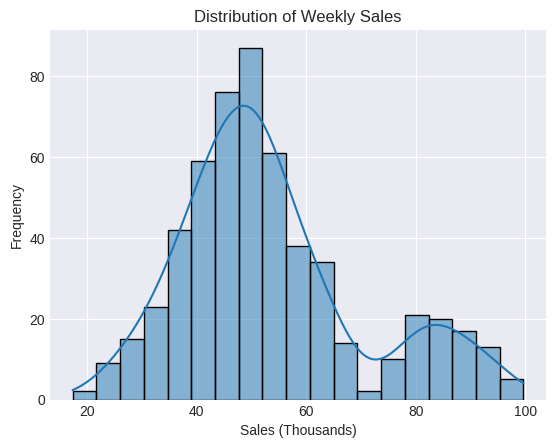

In [12]:
sns.histplot(marketing_food['SalesInThousands'], kde=True)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales (Thousands)")
plt.ylabel("Frequency")

The histogram of weekly sales reveals a **bimodal distribution**, with a primary peak around **50,000** and a secondary peak near **80,000**. This pattern suggests that stores tend to cluster into two distinct sales‑performance groups. The distribution is also **slightly right‑skewed**, with a long tail extending toward higher sales values, indicating the presence of a few high‑performing outliers.


**Market Size:**

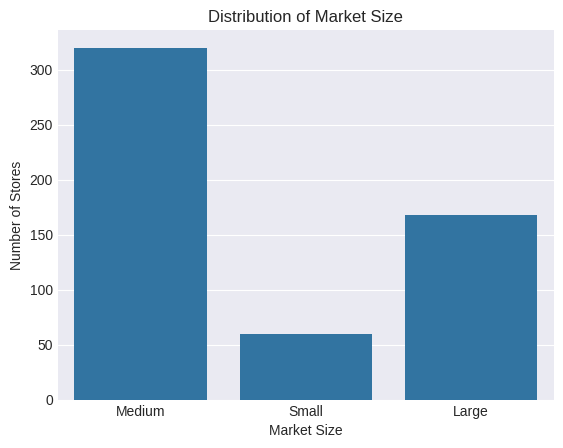

In [13]:
sns.countplot(data=marketing_food, x='MarketSize')
plt.title("Distribution of Market Size")
plt.xlabel("Market Size")
plt.ylabel("Number of Stores")
plt.show()

Market Size is **unevenly distributed** most stores fall into Medium markets, followed by Large markets, while Small markets are significantly under‑represented. This **imbalance may affect analyses** comparing sales or promotion performance across market categories, as **Medium markets will dominate** the results.


**Promotion Categories:**

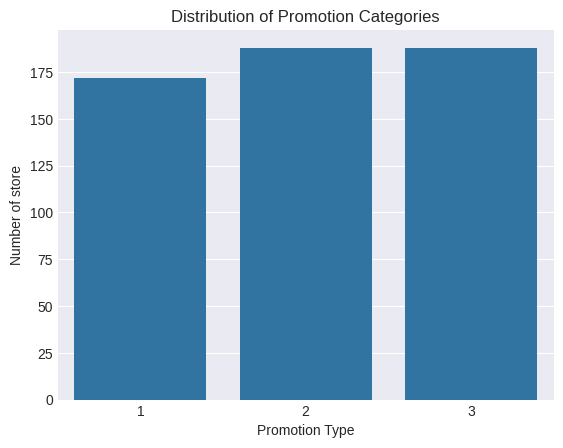

In [14]:
sns.countplot(data=marketing_food, x='Promotion')
plt.title("Distribution of Promotion Categories")
plt.xlabel("Promotion Type")
plt.ylabel("Number of store")
plt.show()

The Promotion categories are **fairly balanced**. Promotions 2 and 3 have slightly more stores just over 185 each, while Promotion 1 has around 170. This **small difference is not significant** and still **allows for reliable comparisons and analysis** across promotion types.

## **Bivariate Analysis:**

A bivariate analysis examines two variables to explore the relationship between them.  We will examine these key variables:
* Sales by Promotion
* Weekly Trends
* Market Size vs Sales




**Sales by Promotion:**

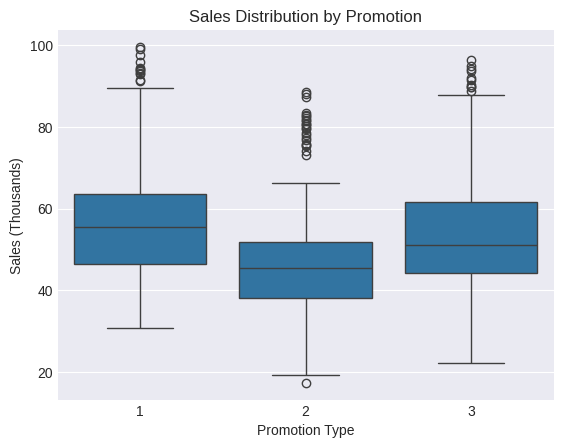

In [15]:
sns.boxplot(data=marketing_food, x='Promotion', y='SalesInThousands')
plt.title("Sales Distribution by Promotion")
plt.xlabel("Promotion Type")
plt.ylabel("Sales (Thousands)")
plt.show()

Promotion Type 1 shows the **highest median sales around 55k**, Promotion Type 2 shows the **lowest median around 45k**, and all three promotions display **high‑end outliers**, most noticeably in Promotions 1 and 3.

**Weekly Trends:**

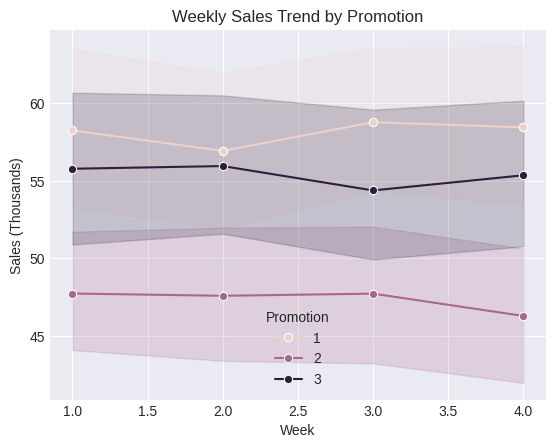

In [16]:
sns.lineplot(data=marketing_food, x='week', y='SalesInThousands', hue='Promotion', marker='o')
plt.title("Weekly Sales Trend by Promotion")
plt.xlabel("Week")
plt.ylabel("Sales (Thousands)")
plt.show()

The line chart shows that average sales change from Week 1 to Week 4, where rising lines indicate **improvement** and falling lines indicate **decline**, with **Promotion 1 growing over time**, and **Promotion 2 showing little to no improvement**.

**Market Size Vs Sales:**

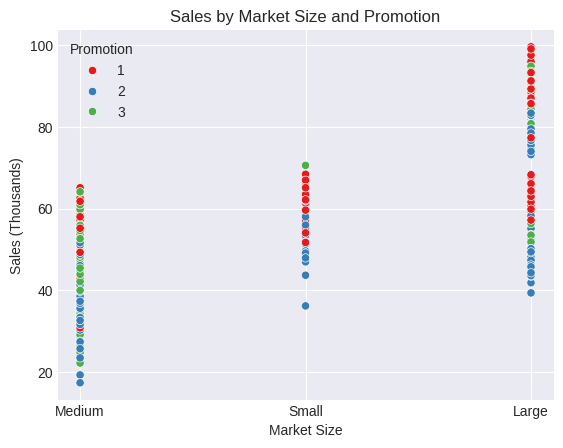

In [17]:
sns.scatterplot(data=marketing_food, x='MarketSize', y='SalesInThousands', hue='Promotion', palette='Set1')
plt.title("Sales by Market Size and Promotion")
plt.xlabel("Market Size")
plt.ylabel("Sales (Thousands)")
plt.show()

The scatter plot shows that **market size is the strongest driver** of sales, with large markets consistently achieving the highest sales regardless of promotion level. And the **higher density of points** in **medium markets** reflects the earlier observation that most stores fall into this category.

# Confirmatory Data Analysis (CDA):
## Statistical Analysis:

**ANOVA Testing:**

We test whether the mean sales differ between the three promotions are statistically significant.

**Hypotheses:**
* null (H₀): All promotions have equal mean sales.
* alternative (H₁): At least one promotion has different mean sales.

In [18]:
Promotion1 = marketing_food[marketing_food['Promotion'] == 1]['SalesInThousands']
Promotion2 = marketing_food[marketing_food['Promotion'] == 2]['SalesInThousands']
Promotion3 = marketing_food[marketing_food['Promotion'] == 3]['SalesInThousands']

f_stat, p_value = stats.f_oneway(Promotion1, Promotion2, Promotion3)

print("F-statistic is:", round(f_stat))
print("p-value is:", p_value)

F-statistic is: 22
p-value is: 6.765849261408714e-10


Since the ANOVA output show a very large F‑statistic ≈ 22, and small p-value = 6.765849261408714e-10 < 0.05, we **reject the null hypothesis (H₀)**. This provides strong statistical evidence that at least one promotion’s mean sales differ from the others.



**Post-hoc Test (Tukey HSD):**

ANOVA tells us "At least one promotion mean sales is different". But it does NOT tell us which one. That’s why we use post‑hoc tests.

**Tukey HSD** (Honest Significant Difference) is a post‑hoc test used after a significant ANOVA to identify which group means differ from each other.

In [19]:
tukey = pairwise_tukeyhsd(
    endog=marketing_food['SalesInThousands'],
    groups=marketing_food['Promotion'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


Based on Tukey HSD post‑hoc testing:

* Promotion 1 is significantly better than Promotion 2.

* Promotion 3 is also significantly better than Promotion 2.

* Promotion 1 and Promotion 3 are not significantly different from each other.

# Summary & Next Steps:


### Key Findings
* Promotion 1 delivers the strongest overall performance.
* Market size is a major driver of sales.
* Promotion 2 underperforms across most metrics.
* Dataset quality is high with no missing or duplicate values.



### Summary:

This A/B test compared three promotions for a new fast‑food item across 548 observations. Promotion 1 delivered the highest sales,  while Promotion 2 consistently underperformed. Market size emerged as a major external factor influencing sales, with large markets outperforming medium and small markets regardless of promotion. ANOVA results confirmed statistically significant differences in mean sales across promotions. Overall, Promotion 1 is the most effective option.



### Limitations
* Only four weeks of data were analyzed
* External factors such as competition and market conditions were not included



### Next Steps
* Extend the experiment to cover more weeks for stronger statistical confidence
* Incorporate customer demographics for deeper segmentation
* Test hybrid or combined promotion strategies


# **Conclusion:**

* Promotions 1 and 3 perform similarly and significantly better.
* Promotion 2 is the worst-performing promotion.


If the company wants the highest sales, they should choose Promotion 1 or Promotion 3.